***Objectives***
1. Preprocess text data (tokenization, removing stopwords, stemming/lemmatization)
2. Use TextBlob for sentiment analysis
3. Visualize sentiment distribution and word frequencies using word clouds

**Dataset:** Social Media Sentiment Dataset  
**Tools:** Python, nltk, TextBlob, pandas, matplotlib, wordcloud

***Step 1: Import Libraries***

We import libraries for text processing (nltk, TextBlob), data manipulation (pandas), and visualization (matplotlib, seaborn, wordcloud).

In [1]:
# Mount Drive & Import Libraries
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from textblob import TextBlob
from wordcloud import WordCloud
from collections import Counter

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

print('All libraries imported and NLTK data downloaded!')

Mounted at /content/drive
All libraries imported and NLTK data downloaded!


***Step 2: Load the Dataset***

Load the social media sentiment dataset and take a first look at its structure, shape, and sample rows.

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/Codveda Technology/Sentiment dataset.csv', index_col=0)

# Drop the extra unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print('Dataset Shape:', df.shape)
print('\nColumns:', list(df.columns))
df.head()

Dataset Shape: (732, 13)

Columns: ['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']


,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [5]:
# Check missing values and data types
print('Missing values:')
print(df.isnull().sum())
print('\nData types:')
print(df.dtypes)

Missing values:
Text         0
Sentiment    0
Timestamp    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
Year         0
Month        0
Day          0
Hour         0
dtype: int64

Data types:
Text          object
Sentiment     object
Timestamp     object
User          object
Platform      object
Hashtags      object
Retweets     float64
Likes        float64
Country       object
Year           int64
Month          int64
Day            int64
Hour           int64
dtype: object


In [6]:
# Clean column names and strip whitespace from text/sentiment
df['Text'] = df['Text'].astype(str).str.strip()
df['Sentiment'] = df['Sentiment'].astype(str).str.strip()

print('Unique Sentiment Labels:', df['Sentiment'].unique())
print('\nSentiment Value Counts:')
print(df['Sentiment'].value_counts())

Unique Sentiment Labels: ['Positive' 'Negative' 'Neutral' 'Anger' 'Fear' 'Sadness' 'Disgust'
 'Happiness' 'Joy' 'Love' 'Amusement' 'Enjoyment' 'Admiration' 'Affection'
 'Awe' 'Disappointed' 'Surprise' 'Acceptance' 'Adoration' 'Anticipation'
 'Bitter' 'Calmness' 'Confusion' 'Excitement' 'Kind' 'Pride' 'Shame'
 'Elation' 'Euphoria' 'Contentment' 'Serenity' 'Gratitude' 'Hope'
 'Empowerment' 'Compassion' 'Tenderness' 'Arousal' 'Enthusiasm'
 'Fulfillment' 'Reverence' 'Despair' 'Grief' 'Loneliness' 'Jealousy'
 'Resentment' 'Frustration' 'Boredom' 'Anxiety' 'Intimidation'
 'Helplessness' 'Envy' 'Regret' 'Curiosity' 'Indifference' 'Numbness'
 'Melancholy' 'Nostalgia' 'Ambivalence' 'Determination' 'Zest' 'Hopeful'
 'Proud' 'Grateful' 'Empathetic' 'Compassionate' 'Playful' 'Free-spirited'
 'Inspired' 'Confident' 'Bitterness' 'Yearning' 'Fearful' 'Apprehensive'
 'Overwhelmed' 'Jealous' 'Devastated' 'Frustrated' 'Envious' 'Dismissive'
 'Thrill' 'Bittersweet' 'Overjoyed' 'Inspiration' 'Motivation'


***Step 3: Exploratory Data Analysis – Sentiment Distribution***

Before processing text, let's understand the distribution of sentiments in the dataset. This helps us understand class balance.

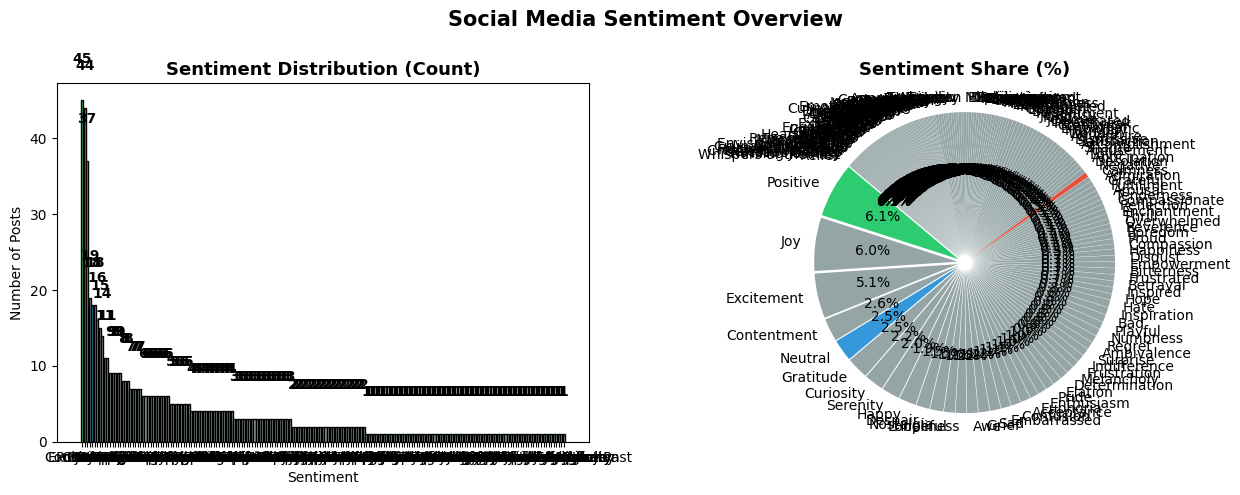

Sentiment distribution plot saved.


In [7]:
sentiment_counts = df['Sentiment'].value_counts()
colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#3498db'}
color_list = [colors.get(s, '#95a5a6') for s in sentiment_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bars = axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=color_list, edgecolor='black')
axes[0].set_title('Sentiment Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Posts')
for bar, v in zip(bars, sentiment_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(v),
                 ha='center', fontweight='bold')

# Pie chart
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index,
            colors=color_list, autopct='%1.1f%%', startangle=140,
            explode=[0.05]*len(sentiment_counts))
axes[1].set_title('Sentiment Share (%)', fontsize=13, fontweight='bold')

plt.suptitle('Social Media Sentiment Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Codveda Technology/sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sentiment distribution plot saved.')

***Step 4: Text Preprocessing***

Raw text is messy. We clean it through:
- **Lowercasing** – normalize case
- **Removing URLs, mentions, hashtags** – strip noise
- **Removing punctuation and numbers** – keep words only
- **Tokenization** – split text into individual words
- **Stopword removal** – remove common words (the, is, at...)
- **Lemmatization** – convert words to their root form (running → run)

In [8]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Full NLP preprocessing pipeline."""
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # 3. Remove @mentions and #hashtags
    text = re.sub(r'[@#]\w+', '', text)
    # 4. Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # 5. Tokenize
    tokens = word_tokenize(text)
    # 6. Remove stopwords and short tokens
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # 7. Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

df['Cleaned_Text'] = df['Text'].apply(preprocess_text)

# Show before / after
print('=== Preprocessing Examples ===')
for i in range(3):
    print(f'\nOriginal:  {df["Text"].iloc[i]}')
    print(f'Processed: {df["Cleaned_Text"].iloc[i]}')

=== Preprocessing Examples ===

Original:  Enjoying a beautiful day at the park!
Processed: enjoying beautiful day park

Original:  Traffic was terrible this morning.
Processed: traffic terrible morning

Original:  Just finished an amazing workout! 💪
Processed: finished amazing workout


***Step 5: Sentiment Analysis with TextBlob***

**TextBlob** computes two scores for any text:
- **Polarity** (–1.0 to +1.0): negative → 0 → positive
- **Subjectivity** (0.0 to 1.0): objective → subjective

We use polarity to classify each post as Positive, Negative, or Neutral and compare to the original dataset labels.

In [9]:
def get_polarity(text):
    return TextBlob(text).sentiment.polarity

def get_subjectivity(text):
    return TextBlob(text).sentiment.subjectivity

def classify_sentiment(polarity):
    if polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Polarity']     = df['Cleaned_Text'].apply(get_polarity)
df['Subjectivity'] = df['Cleaned_Text'].apply(get_subjectivity)
df['TB_Sentiment'] = df['Polarity'].apply(classify_sentiment)

print('Sample results:')
print(df[['Text', 'Sentiment', 'Polarity', 'Subjectivity', 'TB_Sentiment']].head(10))

Sample results:
                                                Text Sentiment  Polarity  \
0              Enjoying a beautiful day at the park!  Positive  0.675000   
1                 Traffic was terrible this morning.  Negative -1.000000   
2                Just finished an amazing workout! 💪  Positive  0.600000   
3        Excited about the upcoming weekend getaway!  Positive  0.375000   
4        Trying out a new recipe for dinner tonight.   Neutral  0.136364   
5    Feeling grateful for the little things in life.  Positive -0.187500   
6   Rainy days call for cozy blankets and hot cocoa.  Positive  0.025000   
7             The new movie release is a must-watch!  Positive  0.136364   
8  Political discussions heating up on the timeline.  Negative  0.000000   
9               Missing summer vibes and beach days.   Neutral -0.200000   

   Subjectivity TB_Sentiment  
0      0.800000     Positive  
1      1.000000     Negative  
2      0.900000     Positive  
3      0.750000     Pos

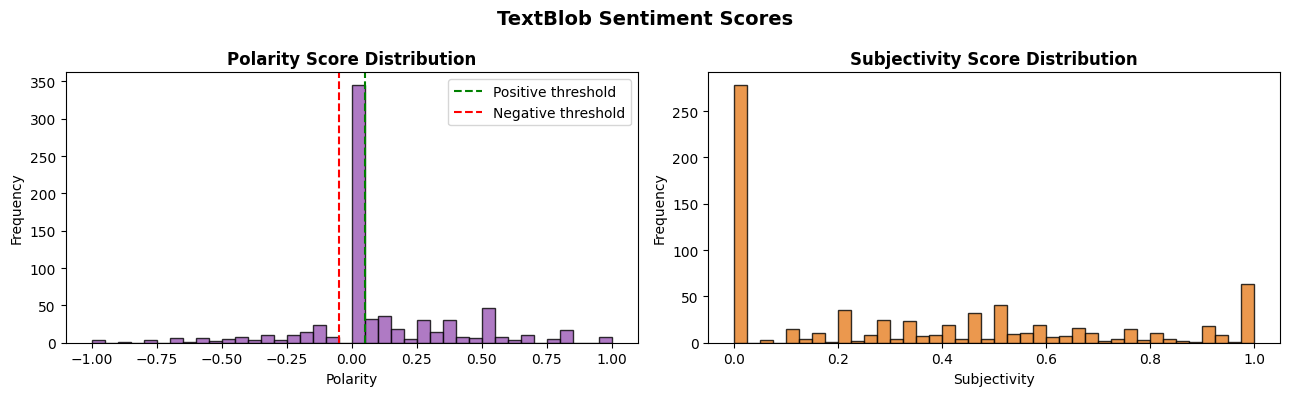

In [10]:
# Polarity and Subjectivity distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Polarity'], bins=40, color='#9b59b6', edgecolor='black', alpha=0.8)
axes[0].axvline(x=0.05, color='green', linestyle='--', label='Positive threshold')
axes[0].axvline(x=-0.05, color='red', linestyle='--', label='Negative threshold')
axes[0].set_title('Polarity Score Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Polarity')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df['Subjectivity'], bins=40, color='#e67e22', edgecolor='black', alpha=0.8)
axes[1].set_title('Subjectivity Score Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Subjectivity')
axes[1].set_ylabel('Frequency')

plt.suptitle('TextBlob Sentiment Scores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Codveda Technology/polarity_subjectivity.png', dpi=150, bbox_inches='tight')
plt.show()

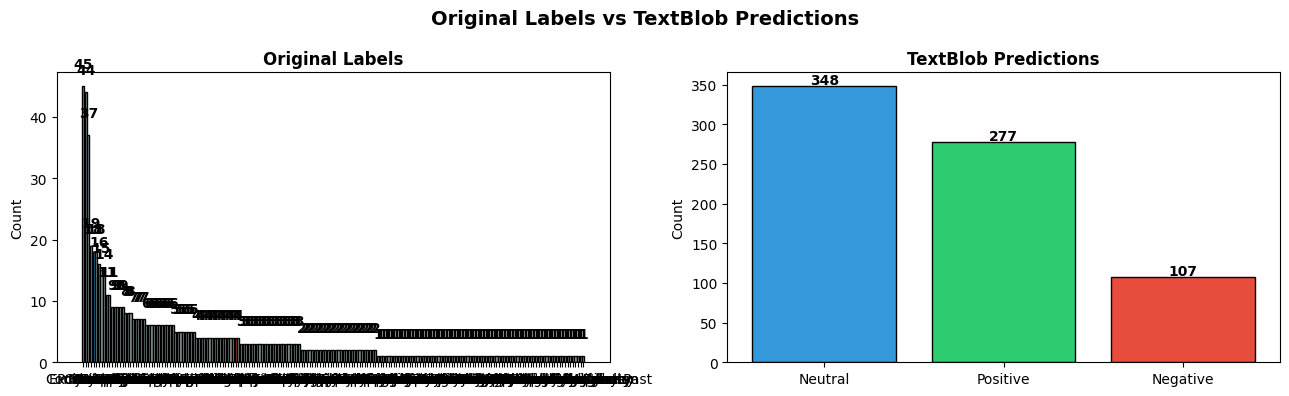

In [11]:
# Compare TextBlob predictions vs original labels
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in zip(
    axes,
    ['Sentiment', 'TB_Sentiment'],
    ['Original Labels', 'TextBlob Predictions']
):
    counts = df[col].value_counts()
    col_colors = [colors.get(s, '#95a5a6') for s in counts.index]
    ax.bar(counts.index, counts.values, color=col_colors, edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 3, str(v), ha='center', fontweight='bold')

plt.suptitle('Original Labels vs TextBlob Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Codveda Technology/label_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

***Step 6: Word Cloud Visualizations***

A **Word Cloud** is a visual representation where the size of each word reflects how frequently it appears in the text. We generate separate clouds for each sentiment to see what words dominate each category.

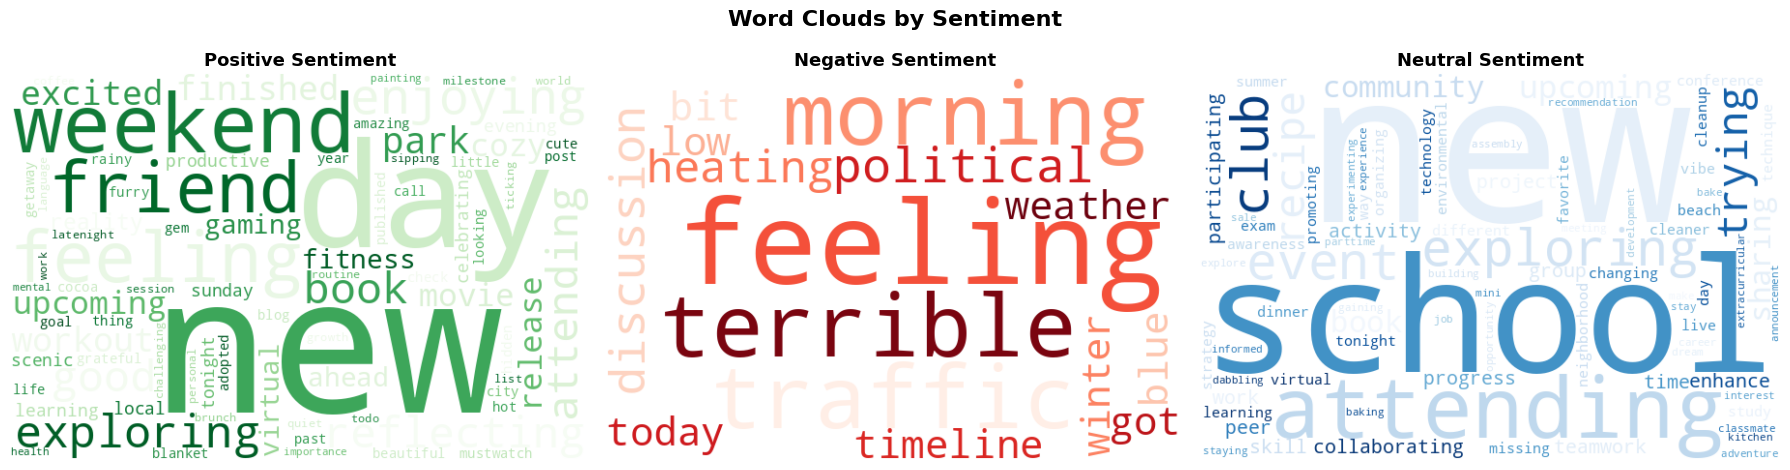

Word clouds saved.


In [12]:
sentiment_colors = {'Positive': 'Greens', 'Negative': 'Reds', 'Neutral': 'Blues'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sentiment in zip(axes, ['Positive', 'Negative', 'Neutral']):
    subset = df[df['Sentiment'] == sentiment]['Cleaned_Text']
    combined_text = ' '.join(subset.dropna())

    if combined_text.strip():
        wc = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap=sentiment_colors[sentiment],
            max_words=80,
            collocations=False
        ).generate(combined_text)
        ax.imshow(wc, interpolation='bilinear')
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)

    ax.axis('off')
    ax.set_title(f'{sentiment} Sentiment', fontsize=13, fontweight='bold')

plt.suptitle('Word Clouds by Sentiment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Codveda Technology/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Word clouds saved.')

***Step 7: Top Word Frequencies per Sentiment***

We extract and plot the top 15 most frequent words for each sentiment class. This reveals the vocabulary associated with positive, negative, and neutral posts.

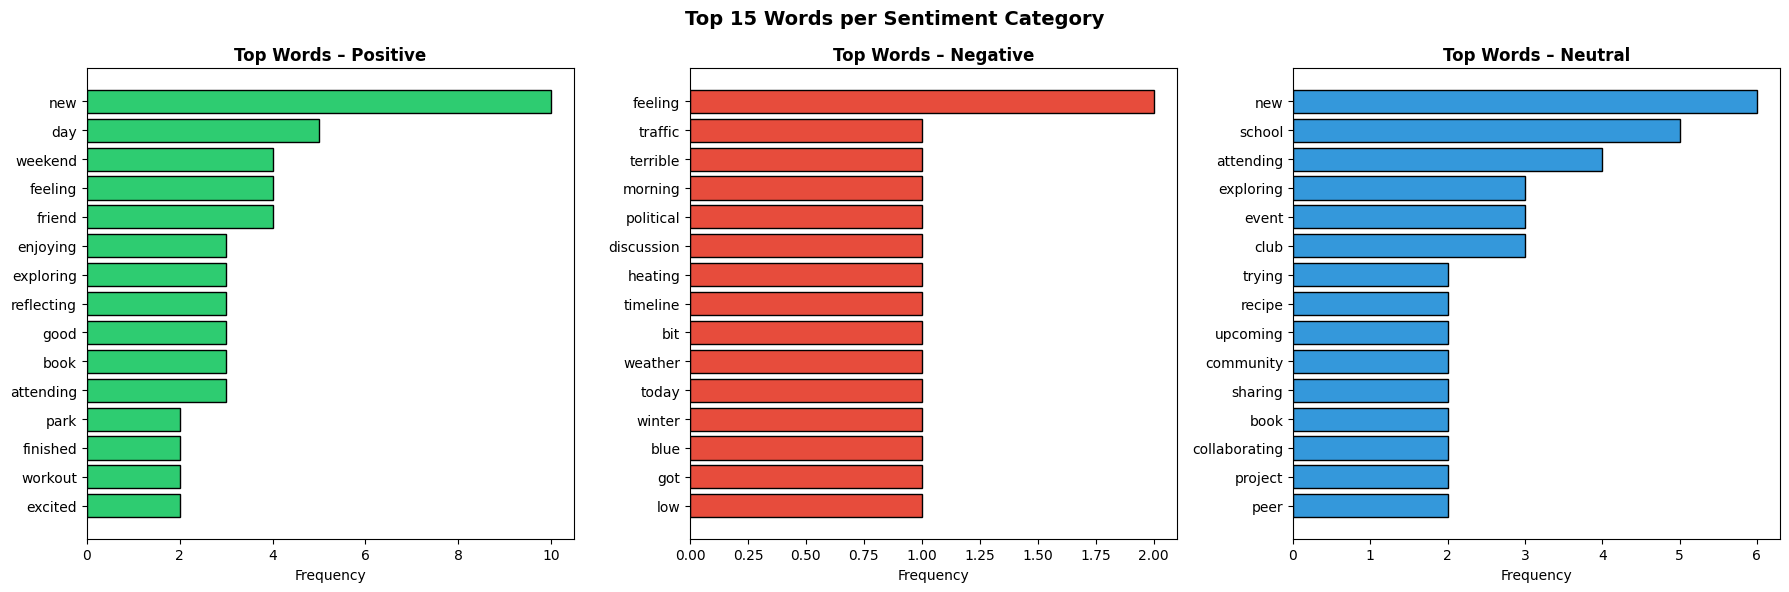

Top words chart saved.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
bar_colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#3498db'}

for ax, sentiment in zip(axes, ['Positive', 'Negative', 'Neutral']):
    subset = df[df['Sentiment'] == sentiment]['Cleaned_Text']
    all_words = ' '.join(subset.dropna()).split()
    freq = Counter(all_words).most_common(15)
    words, counts = zip(*freq) if freq else ([], [])

    ax.barh(words[::-1], counts[::-1], color=bar_colors[sentiment], edgecolor='black')
    ax.set_title(f'Top Words – {sentiment}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Top 15 Words per Sentiment Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Codveda Technology/top_words_per_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top words chart saved.')

***Step 8: Sentiment Trends Over Time***

Since the dataset includes timestamps, we can explore how sentiment changes over time — month by month. This is valuable for detecting shifts in public opinion.

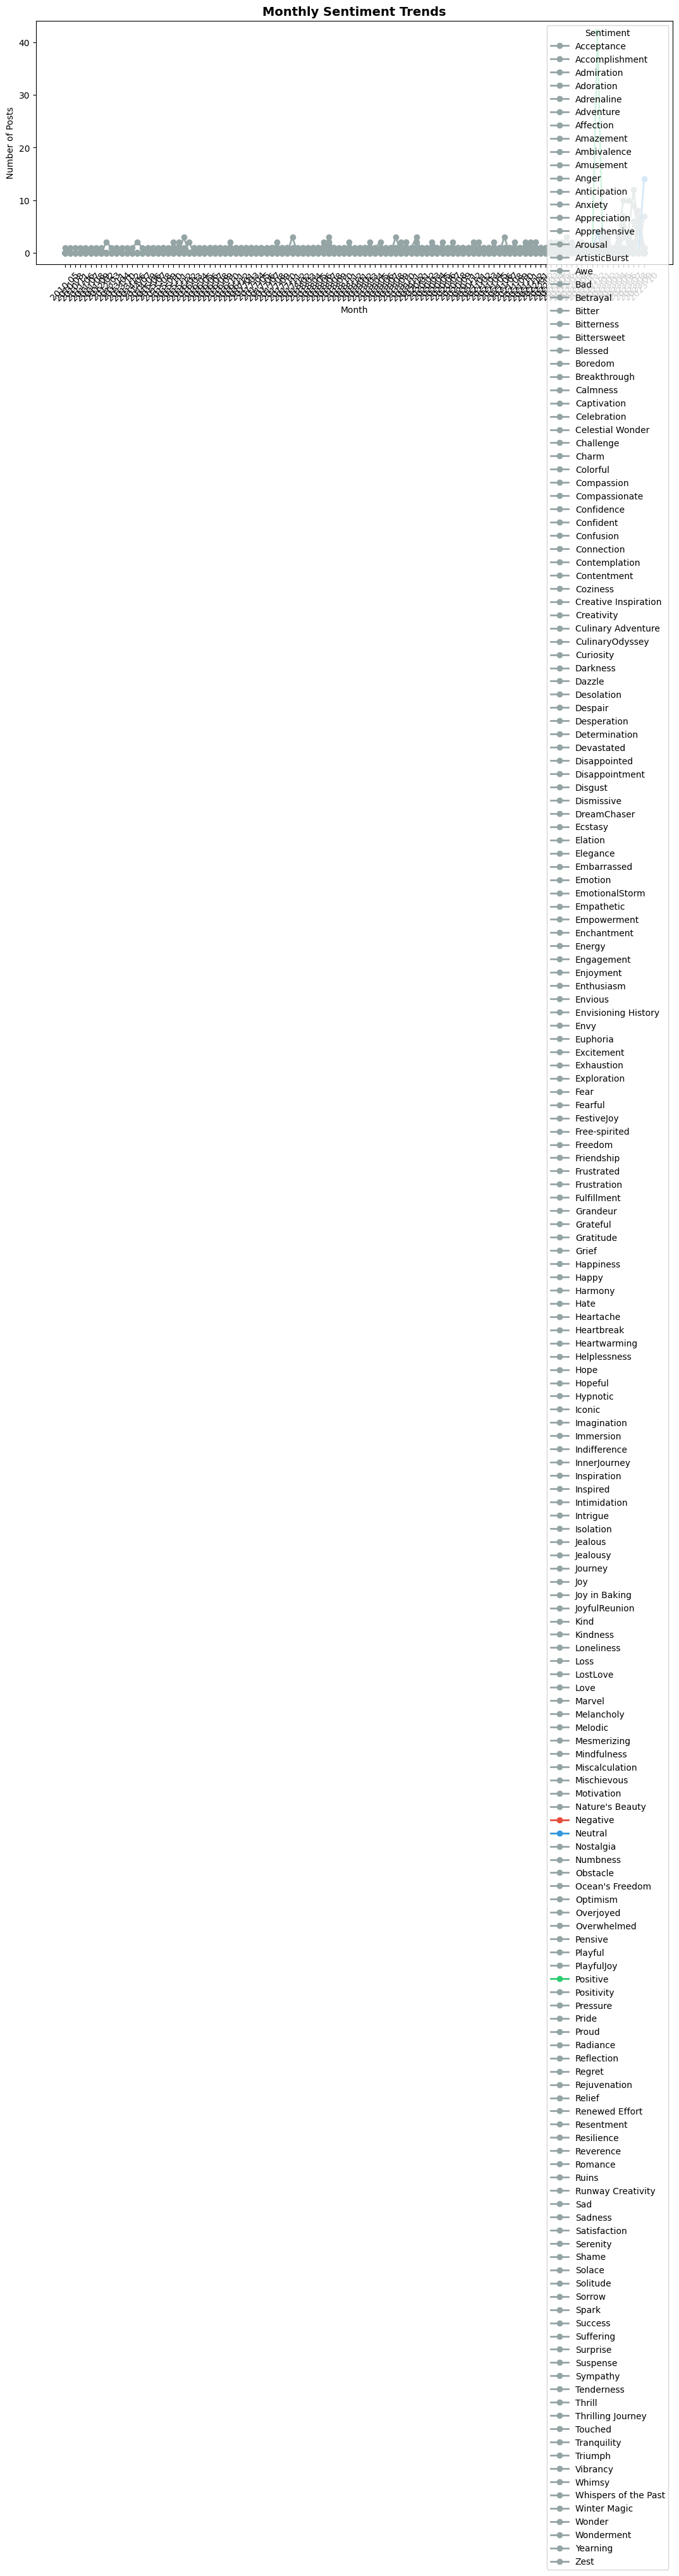

Sentiment trends chart saved.


In [14]:
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df['YearMonth'] = df['Timestamp'].dt.to_period('M')

    monthly = df.groupby(['YearMonth', 'Sentiment']).size().unstack(fill_value=0)

    plt.figure(figsize=(13, 5))
    for sentiment in monthly.columns:
        plt.plot(monthly.index.astype(str), monthly[sentiment],
                 marker='o', label=sentiment,
                 color=colors.get(sentiment, '#95a5a6'), linewidth=2)

    plt.title('Monthly Sentiment Trends', fontsize=14, fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel('Number of Posts')
    plt.xticks(rotation=45)
    plt.legend(title='Sentiment')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/Datasets/Codveda Technology/sentiment_trends.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Sentiment trends chart saved.')
else:
    print('No Timestamp column found – skipping trend analysis.')

***Summary & Conclusions***

### What We Did:
1. **Loaded** the social media sentiment dataset with 732 rows and 14 columns
2. **Preprocessed** text using tokenization, stopword removal, and lemmatization
3. **Analyzed** sentiment using TextBlob's polarity and subjectivity scores
4. **Visualized** sentiment distributions, word clouds, top word frequencies, and monthly trends

### Key Findings:
- The dataset contains a mix of Positive, Negative, and Neutral posts across multiple platforms
- TextBlob predictions tend to classify more posts as Neutral compared to the original labels
- Positive posts commonly contain words like **enjoy**, **love**, **great**, **happy**
- Negative posts commonly contain words like **bad**, **terrible**, **wrong**, **problem**
- Sentiment trends over time can reveal seasonal patterns in public opinion

### Limitations:
- TextBlob uses a lexicon-based approach and may miss context or sarcasm
- For better accuracy, a machine learning–based approach (e.g., fine-tuned BERT) would be more appropriate for production use